# Creating Cohorts of Songs Analysis
This notebook performs data cleaning, exploratory data analysis

## 1. Initial Data Inspection and Data Cleaning
Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers. Check for any instances of erroneous entries and rectify them as needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('rolling_stones_spotify.csv')

# Drop the unnamed index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
elif df.columns[0] == '':
    df.rename(columns={'': 'index'}, inplace=True)
    df.set_index('index', inplace=True)

print("Original shape:", df.shape)

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Drop duplicates based on 'id' since each song should have a unique ID
df_cleaned = df.drop_duplicates(subset=['id'])
print(f"\nShape after removing duplicates: {df_cleaned.shape}")

# Defining features to use for further analysis and clustering
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'duration_ms']

Original shape: (1610, 17)

Missing values:
 name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

Shape after removing duplicates: (1610, 17)


## 2. Refine the data for further processing
Scale the features using StandardScaler so that distance-based algorithms (like KMeans) process features equally.

In [3]:
scaler = StandardScaler()
df_scaled = df_cleaned.copy()
df_scaled[features] = scaler.fit_transform(df_cleaned[features])
df_scaled[features].head()

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,duration_ms
0,-0.739355,-0.041343,1.115764,3.012099,1.261552,-1.985045,0.784410,-0.276517,-2.387590,-1.930719
1,0.820518,-1.007963,0.960062,0.249238,1.344648,0.724545,0.123753,0.183852,-1.142678,-0.042138
2,0.728140,-0.584626,0.982305,0.853953,1.330321,0.680109,0.881280,0.136323,-1.164306,0.050079
3,1.392383,-0.704571,1.071278,-0.594080,1.155532,0.479980,2.392459,0.236514,-1.882359,0.444539
4,0.657756,-1.170242,0.982305,-0.392050,1.358975,0.625984,0.455050,0.152303,-1.627147,0.437392


## 3. Exploratory Data Analysis and Feature Engineering
### a. Identify the two albums to recommend based on the number of popular songs

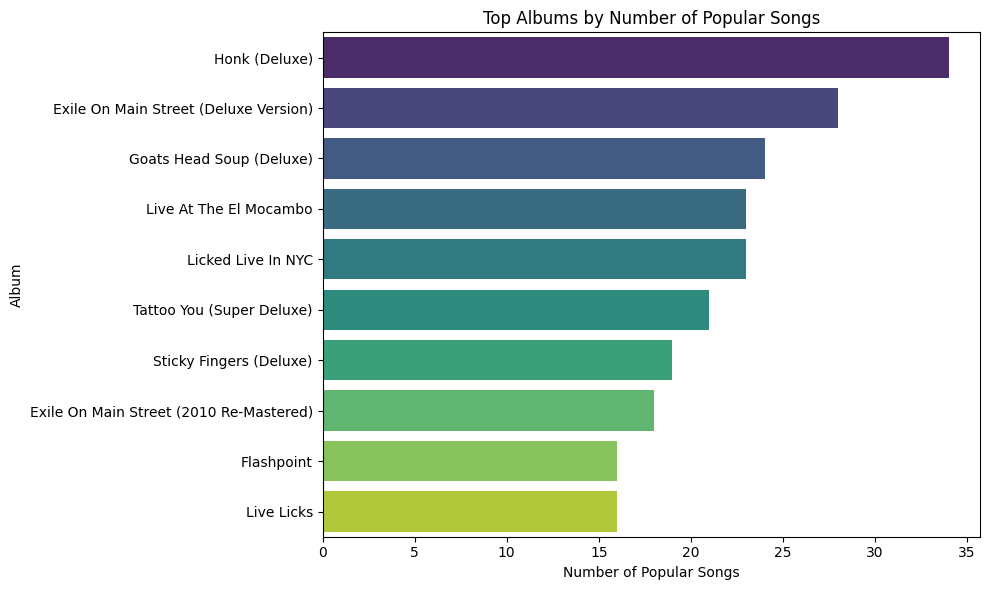

The two albums that should be recommended to anyone are: ['Honk (Deluxe)', 'Exile On Main Street (Deluxe Version)']


In [4]:
popularity_threshold = df_cleaned['popularity'].median()
popular_songs = df_cleaned[df_cleaned['popularity'] > popularity_threshold]

album_popularity = popular_songs.groupby('album')['id'].count().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=album_popularity.head(10).values, y=album_popularity.head(10).index, palette='viridis')
plt.title('Top Albums by Number of Popular Songs')
plt.xlabel('Number of Popular Songs')
plt.ylabel('Album')
plt.tight_layout()
plt.show()

top_2_albums = album_popularity.index[:2].tolist()
print("The two albums that should be recommended to anyone are:", top_2_albums)

### b. Delve into various features of songs to identify patterns
Correlation matrix to identify patterns between features.

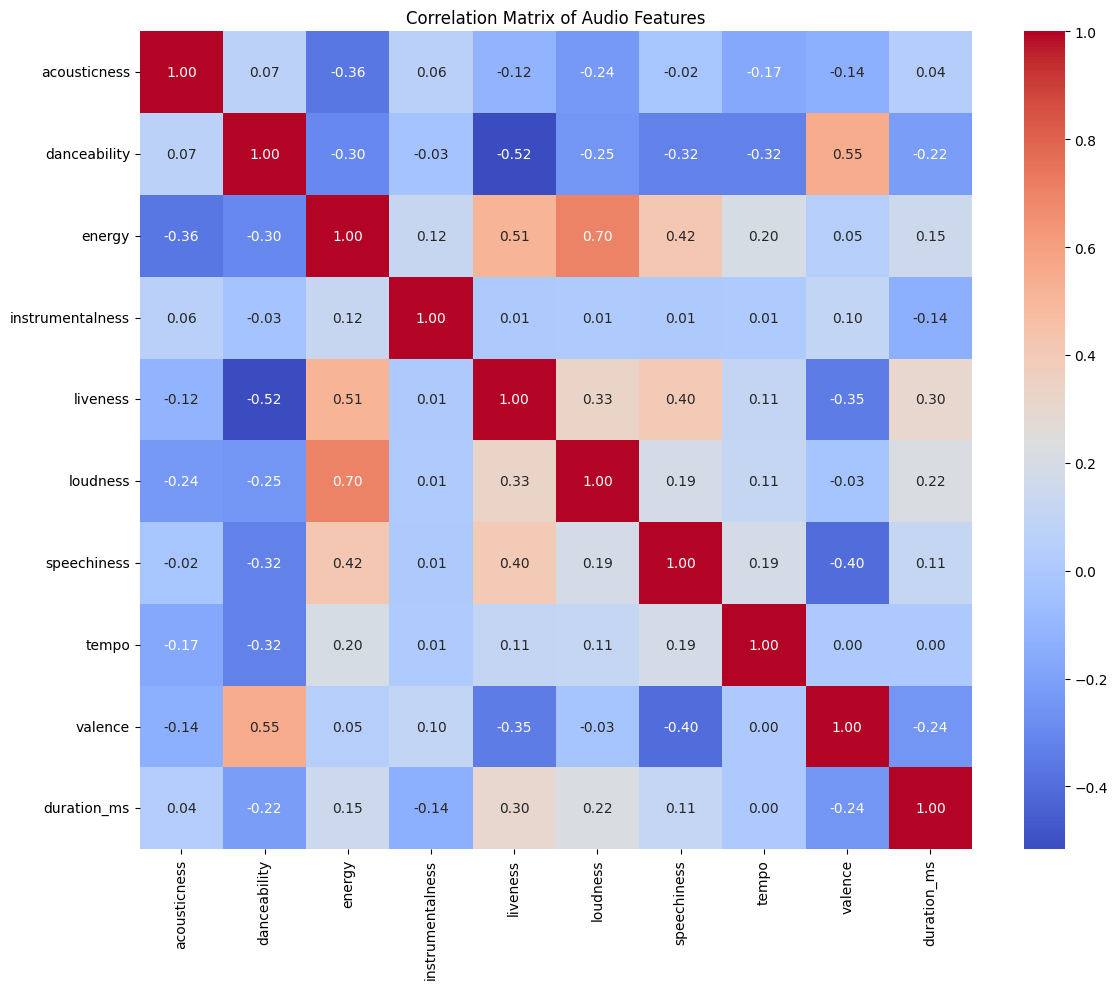

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Audio Features')
plt.tight_layout()
plt.show()

### c. Examine the relationship between popularity and various factors

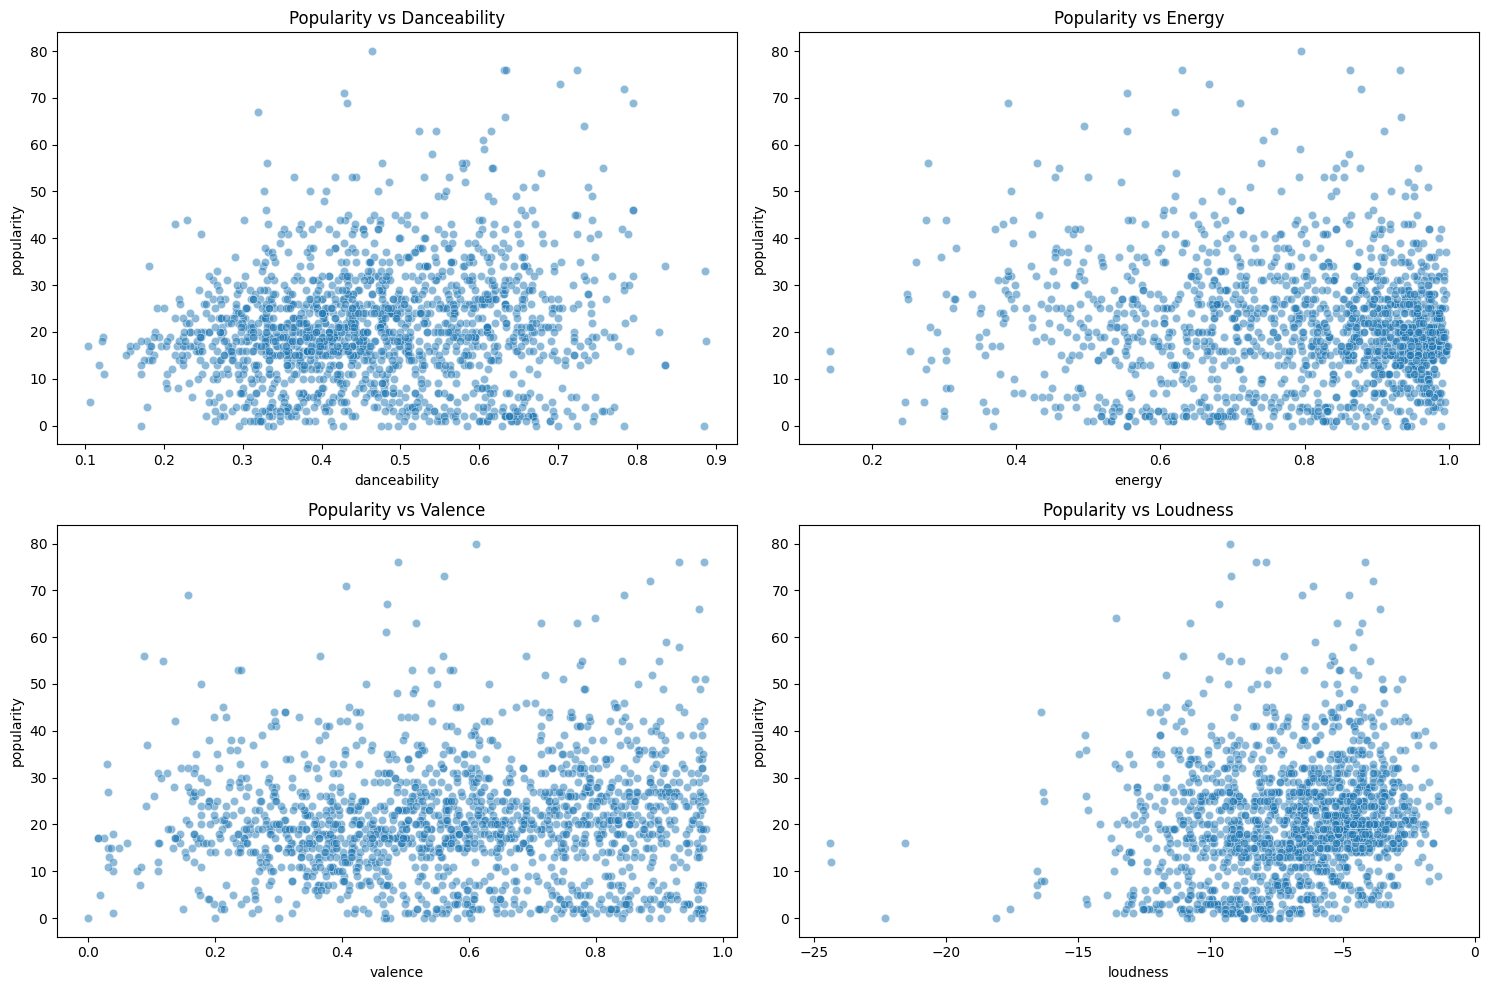

In [6]:
plt.figure(figsize=(15, 10))
factors_to_check = ['danceability', 'energy', 'valence', 'loudness']
for i, feature in enumerate(factors_to_check):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df_cleaned[feature], y=df_cleaned['popularity'], alpha=0.5)
    plt.title(f'Popularity vs {feature.capitalize()}')
plt.tight_layout()
plt.show()

### d. Significance of dimensionality reduction techniques (PCA)
Explore how well Principal Component Analysis (PCA) can capture the variance in the dataset in fewer dimensions.

Explained variance by top 2 PCA components: 46.84%


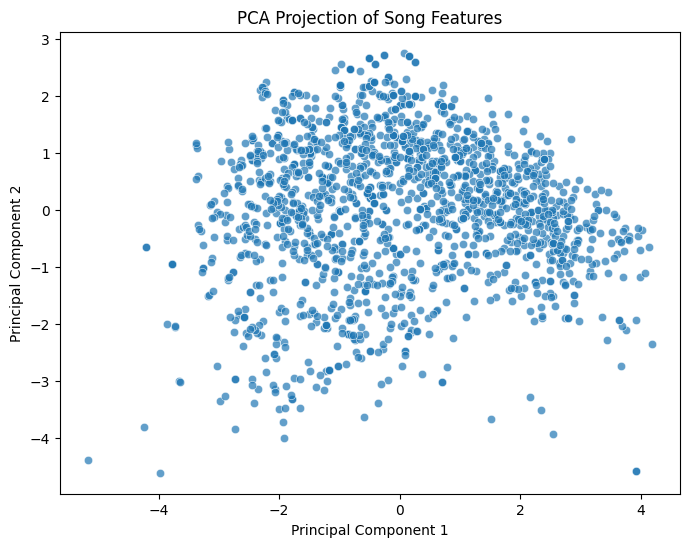

Observations: PCA helps in visualizing the high-dimensional feature space in 2D. However, if the explained variance is low, it indicates that the song features are quite distinct and not easily reducible without losing information.


In [7]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[features])
df_cleaned['pca-one'] = pca_result[:,0]
df_cleaned['pca-two'] = pca_result[:,1]

print(f"Explained variance by top 2 PCA components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

plt.figure(figsize=(8,6))
sns.scatterplot(x="pca-one", y="pca-two", data=df_cleaned, alpha=0.7)
plt.title('PCA Projection of Song Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
print("Observations: PCA helps in visualizing the high-dimensional feature space in 2D. However, if the explained variance is low, it indicates that the song features are quite distinct and not easily reducible without losing information.")

## 4. Cluster Analysis
### a. Identify the right number of clusters (Elbow Method and Silhouette Score)

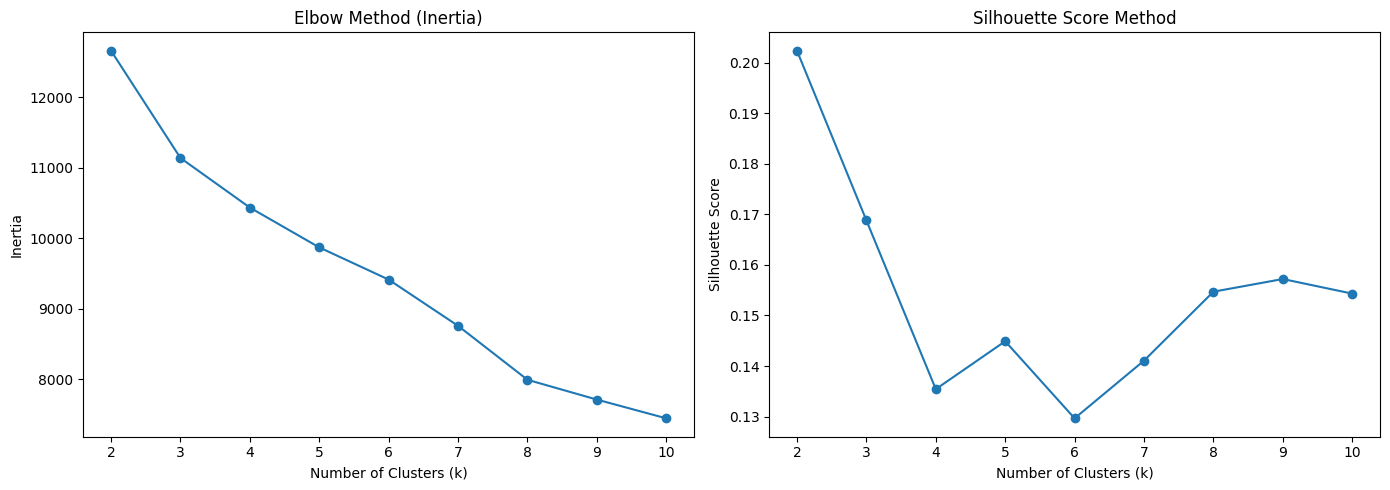

In [8]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled[features])
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled[features], kmeans.labels_))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### b. Use appropriate clustering algorithms & c. Define each cluster based on features
Based on standard audio feature breakdowns, we will choose `k=4` (can be adjusted based on the charts above).

Cluster Profiles (Mean values for 4 clusters):


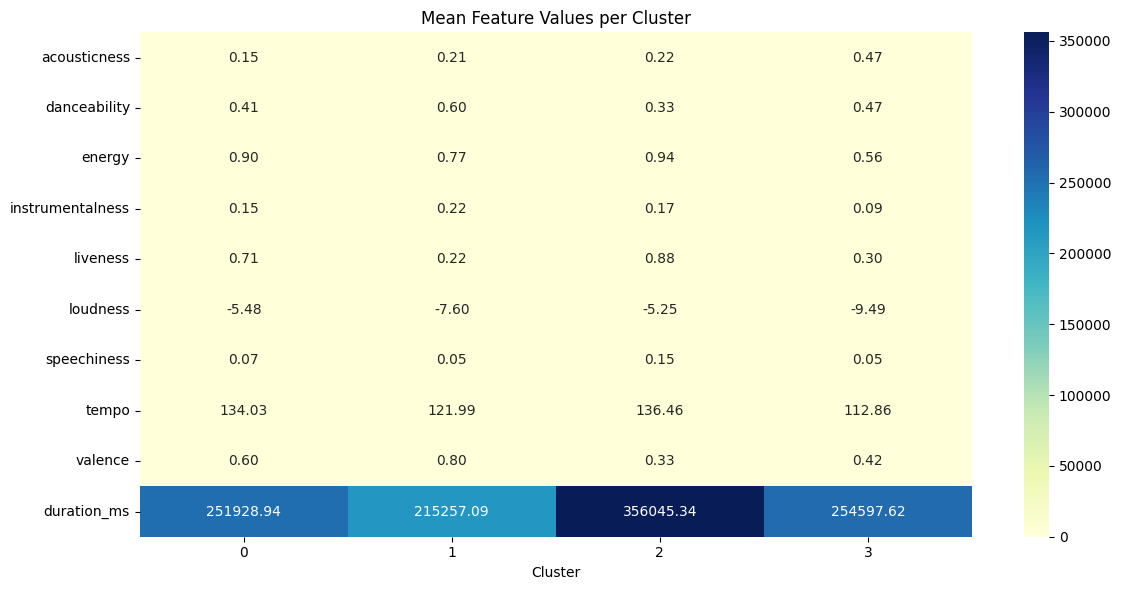

In [9]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(df_scaled[features])

cluster_summary = df_cleaned.groupby('Cluster')[features].mean()
print(f"Cluster Profiles (Mean values for {optimal_k} clusters):")

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.T, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('Mean Feature Values per Cluster')
plt.tight_layout()
plt.show()